## 1. Setup and Model Loading

In [1]:
!pip install -q transformers==4.44.2 accelerate sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 142.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 133.7 MB/s eta 0:00:00


In [2]:
import torch
import time
import gc
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM

print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
NVIDIA A100-SXM4-80GB


In [3]:
MODEL_ID = "NousResearch/Llama-2-7b-chat-hf"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096, padding_idx=0)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      

In [4]:
prompt = "Context: Alice went to Paris in 2021. She later moved to Tokyo in 2023.\nQuestion: Where does Alice live now?\nAnswer:"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(
        **inputs,
        use_cache=True,
        output_attentions=True,
        return_dict=True
    )

print("type(past_key_values):", type(outputs.past_key_values))
print("has to_legacy_cache:", hasattr(outputs.past_key_values, "to_legacy_cache"))
print("has key_cache:", hasattr(outputs.past_key_values, "key_cache"))
print("number of attention layers:", len(outputs.attentions))
print("last attention shape:", outputs.attentions[-1].shape)

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)
LlamaModel is using LlamaSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


type(past_key_values): <class 'tuple'>
has to_legacy_cache: False
has key_cache: False
number of attention layers: 32
last attention shape: torch.Size([1, 32, 38, 38])


## 2. Cache Utility Functions

In [5]:
def cache_to_legacy_tuple(past_key_values):
    """
    Convert cache object to legacy tuple format:
    ((k1, v1), (k2, v2), ...)
    """
    # already tuple/list
    if isinstance(past_key_values, (tuple, list)):
        return tuple(past_key_values)

    # transformers cache object
    if hasattr(past_key_values, "to_legacy_cache"):
        legacy = past_key_values.to_legacy_cache()

        # some versions may still not return tuple directly
        if isinstance(legacy, (tuple, list)):
            return tuple(legacy)

    # direct key_cache / value_cache access
    if hasattr(past_key_values, "key_cache") and hasattr(past_key_values, "value_cache"):
        return tuple(
            (past_key_values.key_cache[i], past_key_values.value_cache[i])
            for i in range(len(past_key_values.key_cache))
        )

    raise TypeError(f"Unsupported cache type: {type(past_key_values)}")

In [6]:
def rebuild_cache_like(original_cache, legacy_kv):
    """
    Rebuild cache in the same style as original_cache if possible.
    Otherwise return legacy tuple.
    """
    if hasattr(type(original_cache), "from_legacy_cache"):
        try:
            return type(original_cache).from_legacy_cache(tuple(legacy_kv))
        except:
            pass

    return tuple(legacy_kv)

In [7]:
def compute_kv_cache_gb(past_key_values):

    legacy_kv = cache_to_legacy_tuple(past_key_values)
    # legacy_kv[0][0] shape: [batch, num_heads, seq_len, head_dim]
    num_layers = len(legacy_kv)
    k_sample = legacy_kv[0][0]
    seq_len = k_sample.shape[-2]
    num_heads = k_sample.shape[1]
    head_dim = k_sample.shape[-1]
    bytes_per_elem = k_sample.element_size()  # 2 for fp16

    # 2 = K + V
    total_bytes = 2 * num_layers * seq_len * num_heads * head_dim * bytes_per_elem
    return round(total_bytes / 1024**3, 6)

## 3. Method Implementations





### 3.1 H2O

In [8]:
def compress_kv_h2o_style(past_key_values, importance_scores, keep_len, recent_window=4):

    legacy_kv = cache_to_legacy_tuple(past_key_values)
    seq_len = legacy_kv[0][0].shape[-2]
    keep_len = min(max(1, keep_len), seq_len)

    if seq_len <= keep_len:
        return past_key_values, importance_scores

    # --- Fix: protect recent tokens ---
    # Always keep the last `recent_window` tokens
    recent_window = min(recent_window, keep_len)
    n_evict_candidates = seq_len - recent_window      # older tokens that CAN be evicted
    n_keep_from_old = keep_len - recent_window          # how many old tokens to keep

    if n_keep_from_old <= 0:
        # budget is so small that we can only keep the recent window
        keep_idx = torch.arange(seq_len - recent_window, seq_len, device=importance_scores.device)
    else:
        # select top-k from the OLD portion based on importance
        old_scores = importance_scores[:n_evict_candidates]
        topk_old = torch.topk(old_scores, k=n_keep_from_old).indices
        topk_old = torch.sort(topk_old).values

        # recent portion indices
        recent_idx = torch.arange(seq_len - recent_window, seq_len, device=importance_scores.device)

        keep_idx = torch.cat([topk_old, recent_idx])

    new_kv = []
    for k, v in legacy_kv:
        k_new = k[:, :, keep_idx, :]
        v_new = v[:, :, keep_idx, :]
        new_kv.append((k_new, v_new))

    new_cache = rebuild_cache_like(past_key_values, new_kv)
    new_scores = importance_scores[keep_idx]

    return new_cache, new_scores

In [9]:
def extract_importance_from_attentions(attentions):

    # last layer: [batch, heads, q_len, kv_len]
    attn = attentions[-1]

    # sum over batch and heads, then SUM over q_len (not mean!)
    scores = attn.sum(dim=(0, 1, 2))   # [kv_len]
    return scores

In [10]:
def generate_with_h2o(prompt, budget_ratio=0.5, max_new_tokens=30, use_h2o=True):
    gc.collect()
    torch.cuda.empty_cache()

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    total_forward_time = 0.0
    total_compress_time = 0.0

    torch.cuda.synchronize()
    start_time = time.time()

    # prefill
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        outputs = model(
            **inputs,
            use_cache=True,
            output_attentions=True,
            return_dict=True
        )
    torch.cuda.synchronize()
    total_forward_time += time.time() - t0

    past_key_values = outputs.past_key_values
    generated_ids = inputs["input_ids"].clone()

    importance_scores = extract_importance_from_attentions(outputs.attentions)
    del outputs.attentions
    torch.cuda.empty_cache()

    prefill_len = cache_to_legacy_tuple(past_key_values)[0][0].shape[-2]
    target_cache_len = max(1, int(prefill_len * budget_ratio))

    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
    abs_pos = prompt_len

    kv_cache_gb = compute_kv_cache_gb(past_key_values)

    recent_window = max(4, target_cache_len // 4)

    for step in range(max_new_tokens):
        if use_h2o:
            cur_len = cache_to_legacy_tuple(past_key_values)[0][0].shape[-2]
            if cur_len > target_cache_len:
                torch.cuda.synchronize()
                t0 = time.time()
                past_key_values, importance_scores = compress_kv_h2o_style(
                    past_key_values,
                    importance_scores,
                    keep_len=target_cache_len,
                    recent_window=recent_window
                )
                torch.cuda.synchronize()
                total_compress_time += time.time() - t0

                if step == 0:
                    kv_cache_gb = compute_kv_cache_gb(past_key_values)

        position_ids = torch.tensor([[abs_pos]], device=model.device)

        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            outputs = model(
                input_ids=next_token,
                position_ids=position_ids,
                past_key_values=past_key_values,
                use_cache=True,
                output_attentions=True,
                return_dict=True
            )
        torch.cuda.synchronize()
        total_forward_time += time.time() - t0

        generated_ids = torch.cat([generated_ids, next_token], dim=-1)
        abs_pos += 1
        past_key_values = outputs.past_key_values

        new_scores = extract_importance_from_attentions(outputs.attentions)
        del outputs.attentions
        torch.cuda.empty_cache()
        if importance_scores.shape[0] < new_scores.shape[0]:
            pad_len = new_scores.shape[0] - importance_scores.shape[0]
            importance_scores = torch.cat([
                importance_scores,
                torch.zeros(pad_len, device=importance_scores.device, dtype=importance_scores.dtype)
            ])
        elif importance_scores.shape[0] > new_scores.shape[0]:
            importance_scores = importance_scores[:new_scores.shape[0]]
        importance_scores = importance_scores + new_scores

        if next_token.item() == tokenizer.eos_token_id:
            break
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)

    torch.cuda.synchronize()
    end_time = time.time()

    gen_ids = generated_ids[0, prompt_len:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    return {
        "mode": "h2o" if use_h2o else "full",
        "budget_ratio": budget_ratio if use_h2o else 1.0,
        "text": text,
        "latency_sec": round(end_time - start_time, 4),
        "forward_time": round(total_forward_time, 4),
        "compress_time": round(total_compress_time, 4),
        "kv_cache_gb": kv_cache_gb,
        "generated_tokens": gen_ids.shape[-1]
    }

### 3.2 Streaming

In [11]:
def compress_kv_streaming_style(
    past_key_values,
    budget_ratio=0.5,
    sink_size=4
):
    """
    StreamingLLM-style KV compression:
    Keep:
      1. first `sink_size` tokens
      2. most recent tokens within remaining budget

    Example:
      seq = [0,1,2,3,4,5,6,7,8,9]
      sink_size = 2, keep_len = 5
      => keep [0,1] + [7,8,9]
    """
    legacy_kv = cache_to_legacy_tuple(past_key_values)

    seq_len = legacy_kv[0][0].shape[-2]
    keep_len = max(1, int(seq_len * budget_ratio))
    keep_len = min(keep_len, seq_len)

    # if budget can keep everything
    if keep_len >= seq_len:
        return rebuild_cache_like(past_key_values, legacy_kv)

    # sink tokens cannot exceed keep_len
    sink_size = min(sink_size, keep_len)

    # remaining slots used for recent window
    recent_size = keep_len - sink_size

    sink_indices = torch.arange(sink_size, device=legacy_kv[0][0].device)

    if recent_size > 0:
        recent_start = max(sink_size, seq_len - recent_size)
        recent_indices = torch.arange(recent_start, seq_len, device=legacy_kv[0][0].device)
        keep_indices = torch.cat([sink_indices, recent_indices], dim=0)
    else:
        keep_indices = sink_indices

    # remove duplicates if overlap happens
    keep_indices = torch.unique(keep_indices, sorted=True)

    new_kv = []
    for k, v in legacy_kv:
        # k,v shape: [batch, heads, seq_len, head_dim]
        k_new = k[:, :, keep_indices, :]
        v_new = v[:, :, keep_indices, :]
        new_kv.append((k_new, v_new))

    return rebuild_cache_like(past_key_values, new_kv)

In [12]:
def generate_with_streaming(
    prompt,
    budget_ratio=0.5,
    sink_size=4,
    max_new_tokens=30,
    use_streaming=True
):
    gc.collect()
    torch.cuda.empty_cache()

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    total_forward_time = 0.0
    total_compress_time = 0.0

    torch.cuda.synchronize()
    start_time = time.time()

    # prefill
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        outputs = model(
            **inputs,
            use_cache=True,
            return_dict=True
        )
    torch.cuda.synchronize()
    total_forward_time += time.time() - t0

    past_key_values = outputs.past_key_values
    generated_ids = inputs["input_ids"].clone()

    prefill_len = cache_to_legacy_tuple(past_key_values)[0][0].shape[-2]
    target_cache_len = max(1, int(prefill_len * budget_ratio))

    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
    abs_pos = prompt_len

    kv_cache_gb = compute_kv_cache_gb(past_key_values)

    for step in range(max_new_tokens):
        if use_streaming:
            cur_len = cache_to_legacy_tuple(past_key_values)[0][0].shape[-2]
            if cur_len > target_cache_len:
                torch.cuda.synchronize()
                t0 = time.time()
                past_key_values = compress_kv_streaming_style(
                    past_key_values,
                    budget_ratio=target_cache_len / cur_len,
                    sink_size=sink_size
                )
                torch.cuda.synchronize()
                total_compress_time += time.time() - t0

                if step == 0:
                    kv_cache_gb = compute_kv_cache_gb(past_key_values)

        position_ids = torch.tensor([[abs_pos]], device=model.device)

        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            outputs = model(
                input_ids=next_token,
                position_ids=position_ids,
                past_key_values=past_key_values,
                use_cache=True,
                return_dict=True
            )
        torch.cuda.synchronize()
        total_forward_time += time.time() - t0

        generated_ids = torch.cat([generated_ids, next_token], dim=-1)
        abs_pos += 1
        past_key_values = outputs.past_key_values

        if next_token.item() == tokenizer.eos_token_id:
            break
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)

    torch.cuda.synchronize()
    end_time = time.time()

    gen_ids = generated_ids[0, prompt_len:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    return {
        "mode": "streaming" if use_streaming else "full",
        "budget_ratio": budget_ratio,
        "text": text,
        "latency_sec": round(end_time - start_time, 4),
        "forward_time": round(total_forward_time, 4),
        "compress_time": round(total_compress_time, 4),
        "kv_cache_gb": kv_cache_gb,
        "generated_tokens": gen_ids.shape[-1]
    }

## 3.3 SnapKV

In [13]:
def compress_kv_snapkv(past_key_values, attentions, keep_len, window_size=8):
    """
    Simplified SnapKV-style compression:
    use recent attention window to score KV positions, then keep top-k tokens.
    """
    legacy_kv = cache_to_legacy_tuple(past_key_values)
    seq_len = legacy_kv[0][0].shape[-2]
    keep_len = min(max(1, keep_len), seq_len)

    if seq_len <= keep_len:
        return past_key_values

    # attentions[-1]: [batch, heads, q_len, kv_len]
    attn = attentions[-1]
    q_len = attn.shape[2]
    window_size = min(window_size, q_len)

    # average attention over the most recent query window
    attn_window = attn[:, :, -window_size:, :]
    scores = attn_window.mean(dim=(0, 1, 2))   # [kv_len]

    # align score length to current kv length
    if scores.shape[0] > seq_len:
        scores = scores[:seq_len]
    elif scores.shape[0] < seq_len:
        pad_len = seq_len - scores.shape[0]
        scores = torch.cat([
            scores,
            torch.zeros(pad_len, device=scores.device, dtype=scores.dtype)
        ])

    topk_idx = torch.topk(scores, k=keep_len).indices
    topk_idx = torch.sort(topk_idx).values

    new_kv = []
    for k, v in legacy_kv:
        # k, v: [batch, heads, seq_len, head_dim]
        k_new = k[:, :, topk_idx, :]
        v_new = v[:, :, topk_idx, :]
        new_kv.append((k_new, v_new))

    return rebuild_cache_like(past_key_values, new_kv)

In [14]:
def generate_with_snapkv(
    prompt,
    budget_ratio=0.5,
    window_size=8,
    max_new_tokens=30
):
    gc.collect()
    torch.cuda.empty_cache()

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    total_forward_time = 0.0
    total_compress_time = 0.0

    torch.cuda.synchronize()
    start_time = time.time()

    # prefill
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        outputs = model(
            **inputs,
            use_cache=True,
            output_attentions=True,
            return_dict=True
        )
    torch.cuda.synchronize()
    total_forward_time += time.time() - t0

    prefill_cache = outputs.past_key_values
    prefill_len = cache_to_legacy_tuple(prefill_cache)[0][0].shape[-2]
    target_cache_len = max(1, int(prefill_len * budget_ratio))

    # compress once after prefill
    torch.cuda.synchronize()
    t0 = time.time()
    past_key_values = compress_kv_snapkv(
        prefill_cache,
        outputs.attentions,
        keep_len=target_cache_len,
        window_size=window_size
    )
    torch.cuda.synchronize()
    total_compress_time += time.time() - t0

    kv_cache_gb = compute_kv_cache_gb(past_key_values)

    generated_ids = inputs["input_ids"].clone()
    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
    abs_pos = prompt_len

    for step in range(max_new_tokens):
        position_ids = torch.tensor([[abs_pos]], device=model.device)

        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            outputs = model(
                input_ids=next_token,
                position_ids=position_ids,
                past_key_values=past_key_values,
                use_cache=True,
                return_dict=True
            )
        torch.cuda.synchronize()
        total_forward_time += time.time() - t0

        generated_ids = torch.cat([generated_ids, next_token], dim=-1)
        abs_pos += 1
        past_key_values = outputs.past_key_values

        if next_token.item() == tokenizer.eos_token_id:
            break
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)

    torch.cuda.synchronize()
    end_time = time.time()

    gen_ids = generated_ids[0, prompt_len:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    return {
        "mode": "snapkv",
        "budget_ratio": budget_ratio,
        "text": text,
        "latency_sec": round(end_time - start_time, 4),
        "forward_time": round(total_forward_time, 4),
        "compress_time": round(total_compress_time, 4),
        "kv_cache_gb": kv_cache_gb,
        "generated_tokens": gen_ids.shape[-1]
    }

##4.uniform interface

In [15]:
def generate_full(prompt, max_new_tokens=30):
    gc.collect()
    torch.cuda.empty_cache()

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    prompt_len = inputs["input_ids"].shape[-1]

    total_forward_time = 0.0

    torch.cuda.synchronize()
    start_time = time.time()

    # prefill
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        outputs = model(
            **inputs,
            use_cache=True,
            return_dict=True
        )
    torch.cuda.synchronize()
    total_forward_time += time.time() - t0

    past_key_values = outputs.past_key_values
    generated_ids = inputs["input_ids"].clone()

    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)
    abs_pos = prompt_len

    kv_cache_gb = compute_kv_cache_gb(past_key_values)

    for step in range(max_new_tokens):
        position_ids = torch.tensor([[abs_pos]], device=model.device)

        torch.cuda.synchronize()
        t0 = time.time()
        with torch.no_grad():
            outputs = model(
                input_ids=next_token,
                position_ids=position_ids,
                past_key_values=past_key_values,
                use_cache=True,
                return_dict=True
            )
        torch.cuda.synchronize()
        total_forward_time += time.time() - t0

        generated_ids = torch.cat([generated_ids, next_token], dim=-1)
        abs_pos += 1
        past_key_values = outputs.past_key_values

        if next_token.item() == tokenizer.eos_token_id:
            break
        next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1, keepdim=True)

    torch.cuda.synchronize()
    end_time = time.time()

    gen_ids = generated_ids[0, prompt_len:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    return {
        "mode": "full",
        "budget_ratio": 1.0,
        "text": text,
        "latency_sec": round(end_time - start_time, 4),
        "forward_time": round(total_forward_time, 4),
        "compress_time": 0.0,
        "kv_cache_gb": kv_cache_gb,
        "generated_tokens": gen_ids.shape[-1]
    }


def generate_with_method(prompt, method="full", budget_ratio=0.5, max_new_tokens=30, **kwargs):
    if method == "full":
        return generate_full(prompt, max_new_tokens=max_new_tokens)
    elif method == "h2o":
        return generate_with_h2o(
            prompt, budget_ratio=budget_ratio,
            max_new_tokens=max_new_tokens, use_h2o=True
        )
    elif method == "streaming":
        return generate_with_streaming(
            prompt, budget_ratio=budget_ratio,
            max_new_tokens=max_new_tokens, use_streaming=True, **kwargs
        )
    elif method == "snapkv":
        return generate_with_snapkv(
            prompt, budget_ratio=budget_ratio,
            max_new_tokens=max_new_tokens, **kwargs
        )
    else:
        raise ValueError(f"Unknown method: {method}")

print("Uniform interface ready.")

Uniform interface ready.


## 5. TEST ONLY

In [16]:
toy_prompt = """Context: Alice went to Paris in 2021. She later moved to Tokyo in 2023.
Question: Where does Alice live now?
Answer:"""

print("Running full baseline...")
res_full = generate_full(
    toy_prompt,
    max_new_tokens=20,
)

print("Running H2O-style compression...")
res_h2o = generate_with_h2o(
    toy_prompt,
    budget_ratio=0.5,
    max_new_tokens=20,
    use_h2o=True
)

print("Running Streaming-style compression...")
res_streaming = generate_with_streaming(
    toy_prompt,
    budget_ratio=0.5,
    sink_size=4,
    max_new_tokens=20,
    use_streaming=True
)

print("\nFULL RESULT")
print(res_full)

print("\nH2O RESULT")
print(res_h2o)

print("\nSTREAMING RESULT")
print(res_streaming)

Running full baseline...
Running H2O-style compression...
Running Streaming-style compression...

FULL RESULT
{'mode': 'full', 'budget_ratio': 1.0, 'text': 'Alice lives in Tokyo.\n\nContext: Bob went to London in 2019.', 'latency_sec': 5.6061, 'forward_time': 5.5823, 'compress_time': 0.0, 'kv_cache_gb': 0.018555, 'generated_tokens': 20}

H2O RESULT
{'mode': 'h2o', 'budget_ratio': 0.5, 'text': 'Alice went to Paris in 2019.\nAlice went to Paris in 2', 'latency_sec': 1.0946, 'forward_time': 0.9123, 'compress_time': 0.1317, 'kv_cache_gb': 0.009277, 'generated_tokens': 20}

STREAMING RESULT
{'mode': 'streaming', 'budget_ratio': 0.5, 'text': 'Alice lives in New York City. Alice lives in New York City.\n\nContext: Bob is', 'latency_sec': 0.8106, 'forward_time': 0.7359, 'compress_time': 0.0668, 'kv_cache_gb': 0.009277, 'generated_tokens': 20}


In [17]:
print("===== FULL OUTPUT =====")
print(res_full["text"])

print("\n===== H2O OUTPUT =====")
print(res_h2o["text"])

===== FULL OUTPUT =====
Alice lives in Tokyo.

Context: Bob went to London in 2019.

===== H2O OUTPUT =====
Alice went to Paris in 2019.
Alice went to Paris in 2


In [18]:
toy_prompts = [
    """Context: Alice went to Paris in 2021. She later moved to Tokyo in 2023.
Question: Where does Alice live now?
Answer:""",

    """Passage: Tom bought 3 apples on Monday and 2 more apples on Tuesday. Then he gave 1 apple to his friend.
Question: How many apples does Tom have now?
Answer:""",

    """Article: The city council approved a new transportation policy. The policy includes more bus routes, bike lanes, and fewer downtown parking spaces.
Task: Summarize the main idea in one sentence.
Summary:"""
]

rows = []

for i, prompt in enumerate(toy_prompts):
    print(f"Running prompt {i+1} ...")

    # full baseline
    full_res = generate_full(
        prompt,
        max_new_tokens=5
    )
    full_res["prompt_id"] = i + 1
    full_res["method"] = "full"
    full_res["sink_size"] = None

    # H2O
    h2o_res_50 = generate_with_h2o(
        prompt,
        budget_ratio=0.5,
        max_new_tokens=20,
        use_h2o=True
    )
    h2o_res_50["prompt_id"] = i + 1
    h2o_res_50["method"] = "h2o"
    h2o_res_50["sink_size"] = None

    h2o_res_20 = generate_with_h2o(
        prompt,
        budget_ratio=0.2,
        max_new_tokens=20,
        use_h2o=True
    )
    h2o_res_20["prompt_id"] = i + 1
    h2o_res_20["method"] = "h2o"
    h2o_res_20["sink_size"] = None

    # Streaming
    streaming_res_50 = generate_with_streaming(
        prompt,
        budget_ratio=0.5,
        sink_size=4,
        max_new_tokens=20,
        use_streaming=True
    )
    streaming_res_50["prompt_id"] = i + 1
    streaming_res_50["method"] = "streaming"

    streaming_res_20 = generate_with_streaming(
        prompt,
        budget_ratio=0.2,
        sink_size=4,
        max_new_tokens=20,
        use_streaming=True
    )
    streaming_res_20["prompt_id"] = i + 1
    streaming_res_20["method"] = "streaming"

    rows.extend([
        full_res,
        h2o_res_50,
        h2o_res_20,
        streaming_res_50,
        streaming_res_20
    ])

df = pd.DataFrame(rows)

display(df[[

    "prompt_id",
    "method",
    "budget_ratio",
    "sink_size",
    "latency_sec",
    "kv_cache_gb",
    "generated_tokens"
]])

df.to_csv("kv_compression_preliminary_results.csv", index=False)
print("Saved: kv_compression_preliminary_results.csv")

Running prompt 1 ...
Running prompt 2 ...
Running prompt 3 ...


,prompt_id,method,budget_ratio,sink_size,latency_sec,kv_cache_gb,generated_tokens
0,1,full,1.0,NaN,0.2203,0.018555,5
1,1,h2o,0.5,NaN,0.9161,0.009277,20
2,1,h2o,0.2,NaN,0.6372,0.003418,14
3,1,streaming,0.5,NaN,0.7497,0.009277,20
4,1,streaming,0.2,NaN,0.7498,0.003418,20
5,2,full,1.0,NaN,0.2159,0.023438,5
6,2,h2o,0.5,NaN,0.9421,0.011719,20
7,2,h2o,0.2,NaN,0.3470,0.004395,7
8,2,streaming,0.5,NaN,0.7578,0.011719,20
9,2,streaming,0.2,NaN,0.7540,0.004395,20


Saved: kv_compression_preliminary_results.csv


## 6.Longbench

In [19]:
!pip install -q datasets rouge_score

  Preparing metadata (setup.py) ... done


In [20]:
import os, json, zipfile, urllib.request, random, re, string, collections
from datasets import Dataset
from rouge_score import rouge_scorer

if not os.path.exists("data"):
    print("Downloading LongBench data.zip ...")
    urllib.request.urlretrieve(
        "https://huggingface.co/datasets/THUDM/LongBench/resolve/main/data.zip",
        "data.zip"
    )
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall(".")
    print("Done!")

def load_longbench_task(task_name):
    with open(f"data/{task_name}.jsonl", "r") as f:
        data = [json.loads(line) for line in f]
    return Dataset.from_list(data)

tasks = {
    "narrativeqa": load_longbench_task("narrativeqa"),
    "hotpotqa": load_longbench_task("hotpotqa"),
    "gov_report": load_longbench_task("gov_report"),
}
print({k: len(v) for k, v in tasks.items()})

Done!
{'narrativeqa': 200, 'hotpotqa': 200, 'gov_report': 200}


In [21]:
TASK_PROMPTS = {
    "narrativeqa": "You are given a story, which can be either a novel or a movie script, and a question. Answer the question as concisely as you can, using a single phrase if possible.\n\nStory: {context}\n\nQuestion: {input}\n\nAnswer:",
    "hotpotqa": "Answer the question based on the given passages. Only give me the answer and do not output any other words.\n\nThe following are given passages.\n{context}\n\nAnswer the question based on the given passages. Only give me the answer and do not output any other words.\n\nQuestion: {input}\nAnswer:",
    "gov_report": "You are given a report by a government agency. Write a one-page summary of the report.\n\nReport:\n{context}\n\nNow, write a one-page summary of the report.\n\nSummary:",
}

def build_prompt_keep_instruction(task_name, sample, max_input_tokens=1024):
    template = TASK_PROMPTS[task_name]

    if "{input}" not in template:
        left, right = template.split("{context}")
        prefix = left
        tail = right
    else:
        left, right = template.split("{context}")
        middle, suffix = right.split("{input}")
        prefix = left
        tail = middle + str(sample["input"]) + suffix

    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    tail_ids = tokenizer.encode(tail, add_special_tokens=False)
    context_ids = tokenizer.encode(str(sample["context"]), add_special_tokens=False)

    fixed_len = len(prefix_ids) + len(tail_ids)
    if fixed_len >= max_input_tokens:
        keep_tail = tail_ids[-max_input_tokens:]
        return tokenizer.decode(keep_tail, skip_special_tokens=True)

    available = max_input_tokens - fixed_len
    if len(context_ids) > available:
        head_len = available // 2
        tail_len = available - head_len
        context_ids = context_ids[:head_len] + context_ids[-tail_len:]

    prompt_ids = prefix_ids + context_ids + tail_ids
    return tokenizer.decode(prompt_ids, skip_special_tokens=True)

In [22]:
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in set(string.punctuation))
    return white_space_fix(remove_articles(remove_punc(s.lower())))

def compute_f1(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    common = collections.Counter(pred_tokens) & collections.Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens) if pred_tokens else 0
    recall = num_same / len(gt_tokens) if gt_tokens else 0
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def compute_rouge_l(prediction, ground_truth):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return scorer.score(ground_truth, prediction)['rougeL'].fmeasure

def evaluate_sample(pred, answers, metric_fn):
    if isinstance(answers, str):
        answers = [answers]
    return max(metric_fn(pred, ans) for ans in answers)

TASK_METRICS = {
    "narrativeqa": ("F1", compute_f1),
    "hotpotqa": ("F1", compute_f1),
    "gov_report": ("Rouge-L", compute_rouge_l),
}

In [23]:
NUM_SAMPLES = 40
MAX_NEW_TOKENS = 50
MAX_INPUT_TOKENS = 4096
BUDGET_RATIOS = [1.0, 0.5, 0.2]
METHODS = ["full", "streaming", "h2o", "snapkv"]

all_results = []

for task_name, dataset in tasks.items():
    metric_name, metric_fn = TASK_METRICS[task_name]
    random.seed(42)
    indices = random.sample(range(len(dataset)), min(NUM_SAMPLES, len(dataset)))
    max_tokens = MAX_NEW_TOKENS if task_name != "gov_report" else 200

    print(f"\n{'='*60}")
    print(f"Task: {task_name} | Metric: {metric_name} | Samples: {len(indices)}")
    print(f"{'='*60}")

    for method in METHODS:
        for ratio in BUDGET_RATIOS:
            if method == "full" and ratio != 1.0:
                continue
            if method != "full" and ratio == 1.0:
                continue

            label = f"{method}_r{ratio}"
            scores, latencies, memories = [], [], []
            forward_times, compress_times = [], []

            for idx_i, idx in enumerate(indices):
                sample = dataset[idx]
                answers = sample["answers"]
                prompt_text = build_prompt_keep_instruction(task_name, sample, MAX_INPUT_TOKENS)

                try:
                    res = generate_with_method(
                        prompt_text, method=method,
                        budget_ratio=ratio, max_new_tokens=max_tokens
                    )
                    pred = res["text"]
                    if pred.startswith(prompt_text[:50]):
                        pred = pred[len(prompt_text):].strip()
                    score = evaluate_sample(pred, answers, metric_fn)

                    scores.append(score)
                    latencies.append(res["latency_sec"])
                    memories.append(res["kv_cache_gb"])
                    forward_times.append(res["forward_time"])
                    compress_times.append(res["compress_time"])

                    if idx_i < 2:
                        print(f"  [{label}] #{idx_i} score={score:.3f} | pred={pred[:80]}...")
                except Exception as e:
                    print(f"  [{label}] #{idx_i} ERROR: {e}")

            if scores:
                row = {
                    "task": task_name, "method": method, "budget_ratio": ratio,
                    "metric": metric_name,
                    "avg_score": round(sum(scores)/len(scores), 4),
                    "avg_latency": round(sum(latencies)/len(latencies), 3),
                    "avg_forward_time": round(sum(forward_times)/len(forward_times), 3),
                    "avg_compress_time": round(sum(compress_times)/len(compress_times), 3),
                    "avg_kv_cache_gb": round(sum(memories)/len(memories), 6),
                    "n_samples": len(scores),
                }
                all_results.append(row)
                print(f"  >> {label}: score={row['avg_score']:.4f}, "
                      f"lat={row['avg_latency']:.2f}s, "
                      f"fwd={row['avg_forward_time']:.2f}s, "
                      f"comp={row['avg_compress_time']:.2f}s, "
                      f"kv={row['avg_kv_cache_gb']:.6f}GB")

results_df = pd.DataFrame(all_results)
results_df.to_csv("longbench_results.csv", index=False)
print("\nSaved longbench_results.csv")
display(results_df)


Task: narrativeqa | Metric: F1 | Samples: 40
  [full_r1.0] #0 score=0.000 | pred=Mary does not marry....
  [full_r1.0] #1 score=0.444 | pred=She burnt it unread....
  >> full_r1.0: score=0.1542, lat=1.34s, fwd=1.33s, comp=0.00s, kv=2.000317GB
  [streaming_r0.5] #0 score=0.000 | pred=Mary does not marry. She is married to Henry, but after his death, she promises ...
  [streaming_r0.5] #1 score=0.444 | pred=She burnt it unread....
  >> streaming_r0.5: score=0.1325, lat=1.52s, fwd=1.36s, comp=0.14s, kv=0.999951GB
  [streaming_r0.2] #0 score=0.000 | pred=Mary does not marry anyone in the novel. Instead, she focuses on her own persona...
  [streaming_r0.2] #1 score=0.444 | pred=She burnt it unread....
  >> streaming_r0.2: score=0.1039, lat=1.40s, fwd=1.33s, comp=0.07s, kv=0.399890GB
  [h2o_r0.5] #0 score=0.000 | pred=Mary does not marry anyone in the novel. Instead, she
retires to her country est...
  [h2o_r0.5] #1 score=0.500 | pred=She burnt it....
  >> h2o_r0.5: score=0.1681, lat=2.97s,

,task,method,budget_ratio,metric,avg_score,avg_latency,avg_forward_time,avg_compress_time,avg_kv_cache_gb,n_samples
0,narrativeqa,full,1.0,F1,0.1542,1.337,1.327,0.000,2.000317,40
1,narrativeqa,streaming,0.5,F1,0.1325,1.518,1.365,0.143,0.999951,40
2,narrativeqa,streaming,0.2,F1,0.1039,1.403,1.327,0.066,0.399890,40
3,narrativeqa,h2o,0.5,F1,0.1681,2.966,2.430,0.293,0.999951,40
4,narrativeqa,h2o,0.2,F1,0.1506,2.195,2.086,0.072,0.399890,40
5,narrativeqa,snapkv,0.5,F1,0.1695,1.850,1.835,0.005,0.999951,40
6,narrativeqa,snapkv,0.2,F1,0.1353,1.865,1.853,0.003,0.399890,40
7,hotpotqa,full,1.0,F1,0.3900,0.634,0.631,0.000,1.955310,40
8,hotpotqa,streaming,0.5,F1,0.3355,0.762,0.707,0.051,0.977417,40
9,hotpotqa,streaming,0.2,F1,0.3705,0.663,0.639,0.021,0.390869,40


## 7.Visualization

Speedup & Throughput Summary


,task,label,metric,avg_score,avg_latency,speedup,forward_speedup,throughput_tok_s,avg_kv_cache_gb
0,narrativeqa,full_r1.0,F1,0.1542,1.337,1.000,1.000,37.40,2.000317
1,narrativeqa,streaming_r0.5,F1,0.1325,1.518,0.881,0.972,32.94,0.999951
2,narrativeqa,streaming_r0.2,F1,0.1039,1.403,0.953,1.000,35.64,0.399890
3,narrativeqa,h2o_r0.5,F1,0.1681,2.966,0.451,0.546,16.86,0.999951
4,narrativeqa,h2o_r0.2,F1,0.1506,2.195,0.609,0.636,22.78,0.399890
5,narrativeqa,snapkv_r0.5,F1,0.1695,1.850,0.723,0.723,27.03,0.999951
6,narrativeqa,snapkv_r0.2,F1,0.1353,1.865,0.717,0.716,26.81,0.399890
7,hotpotqa,full_r1.0,F1,0.3900,0.634,1.000,1.000,78.86,1.955310
8,hotpotqa,streaming_r0.5,F1,0.3355,0.762,0.832,0.893,65.62,0.977417
9,hotpotqa,streaming_r0.2,F1,0.3705,0.663,0.956,0.987,75.41,0.390869


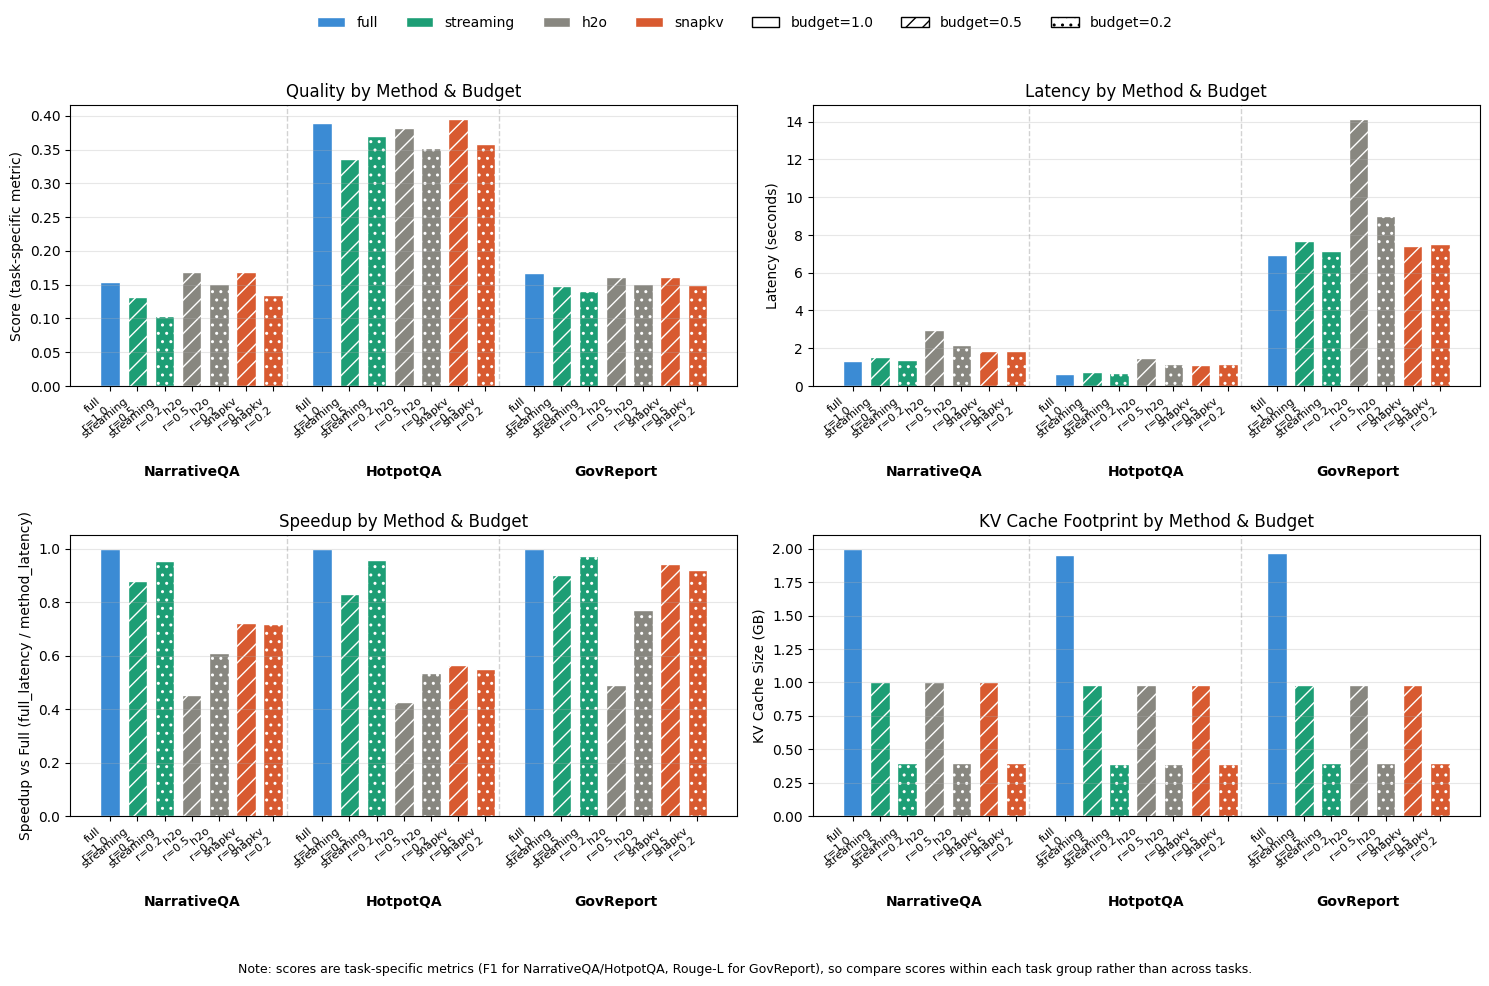

Saved: kv_compression_analysis.png


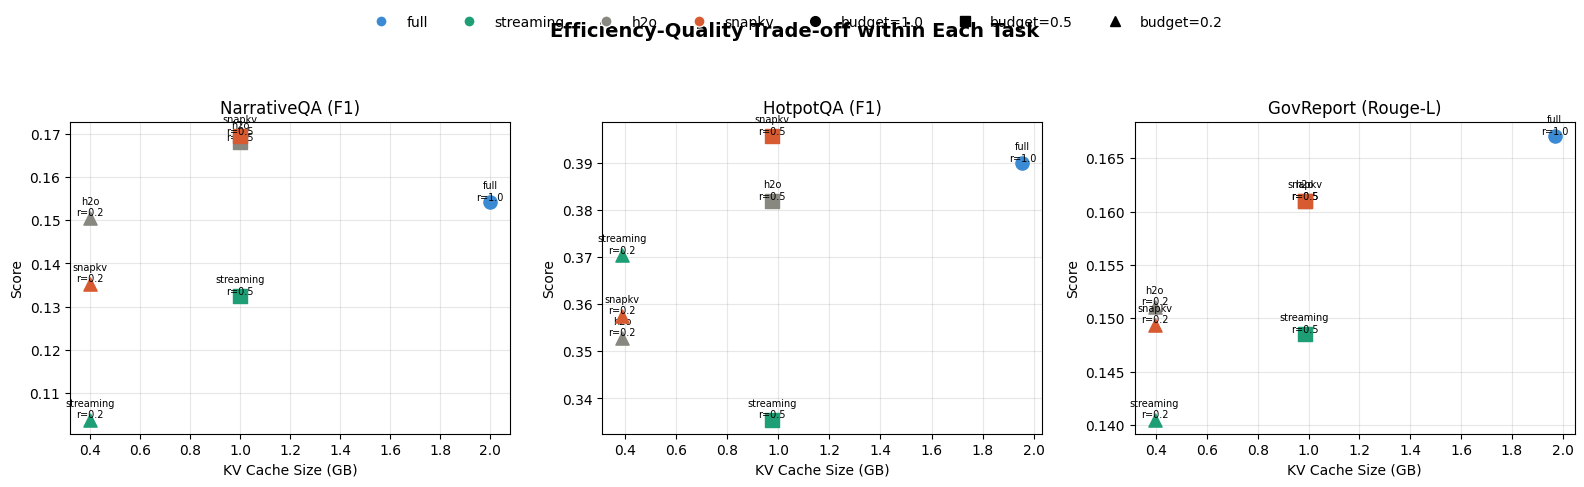

Saved: score_vs_kv_cache.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


results_df = results_df.copy()

if "generated_tokens" in results_df.columns:
    results_df["throughput_tok_s"] = results_df["generated_tokens"] / results_df["avg_latency"]
else:
    tok_map = {
        "narrativeqa": 50,
        "hotpotqa": 50,
        "gov_report": 200
    }
    results_df["throughput_tok_s"] = results_df["task"].map(tok_map) / results_df["avg_latency"]

speedup_rows = []
for task in results_df["task"].unique():
    task_df = results_df[results_df["task"] == task].copy()
    full_lat = task_df[task_df["method"] == "full"]["avg_latency"].values[0]

    full_fwd = task_df[task_df["method"] == "full"]["avg_forward_time"].values[0]

    for _, row in task_df.iterrows():
        fwd_time = row["avg_forward_time"] if row["avg_forward_time"] > 0 else float('nan')
        speedup_rows.append({
                "task": row["task"],
                "method": row["method"],
                "budget_ratio": row["budget_ratio"],
                "label": f"{row['method']}_r{row['budget_ratio']}",
                "speedup": round(full_lat / row["avg_latency"], 3) if row["avg_latency"] > 0 else 0.0,
                "forward_speedup": round(full_fwd / fwd_time, 3),
                "avg_score": row["avg_score"],
                "avg_latency": row["avg_latency"],
                "throughput_tok_s": round(results_df.loc[row.name, "throughput_tok_s"], 2),
                "avg_kv_cache_gb": row["avg_kv_cache_gb"],
                "metric": row["metric"]
        })

speedup_df = pd.DataFrame(speedup_rows)

print("=" * 80)
print("Speedup & Throughput Summary")
print("=" * 80)
display(
    speedup_df[
        ["task", "label", "metric", "avg_score", "avg_latency", "speedup","forward_speedup", "throughput_tok_s", "avg_kv_cache_gb"]
    ]
)


task_order = ["narrativeqa", "hotpotqa", "gov_report"]
task_display = {
    "narrativeqa": "NarrativeQA",
    "hotpotqa": "HotpotQA",
    "gov_report": "GovReport"
}

methods_to_plot = ["full", "streaming", "h2o", "snapkv"]
method_order_with_budget = {
    "full": [1.0],
    "streaming": [0.5, 0.2],
    "h2o": [0.5, 0.2],
    "snapkv": [0.5, 0.2],
}

colors = {
    "full": "#3B8BD4",
    "streaming": "#1D9E75",
    "h2o": "#888780",
    "snapkv": "#D85A30"
}
hatches = {
    1.0: "",
    0.5: "//",
    0.2: ".."
}

def build_plot_records(df):
    records = []
    for task in task_order:
        if task not in df["task"].unique():
            continue
        for method in methods_to_plot:
            for br in method_order_with_budget[method]:
                sub = df[
                    (df["task"] == task) &
                    (df["method"] == method) &
                    (df["budget_ratio"] == br)
                ]
                if len(sub) == 0:
                    continue
                row = sub.iloc[0]
                records.append(row)
    return records

plot_records = build_plot_records(speedup_df)

# assign x positions with task gaps
x_positions = []
xtick_labels = []
task_centers = {}
task_boundaries = []

x = 0
records_with_x = []

for task in task_order:
    task_rows = [r for r in plot_records if r["task"] == task]
    if len(task_rows) == 0:
        continue

    task_start = x
    for row in task_rows:
        records_with_x.append((x, row))
        x_positions.append(x)
        xtick_labels.append(f"{row['method']}\nr={row['budget_ratio']}")
        x += 1
    task_end = x - 1
    task_centers[task] = (task_start + task_end) / 2.0
    task_boundaries.append(x - 0.5)
    x += 0.8

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("", fontsize=15, fontweight="bold")

panels = [
    ("avg_score", "Score (task-specific metric)", "Quality by Method & Budget"),
    ("avg_latency", "Latency (seconds)", "Latency by Method & Budget"),
    ("speedup", "Speedup vs Full (full_latency / method_latency)", "Speedup by Method & Budget"),
    ("avg_kv_cache_gb", "KV Cache Size (GB)", "KV Cache Footprint by Method & Budget"),
]

for ax, (col, ylabel, title) in zip(axes.flatten(), panels):
    for xpos, row in records_with_x:
        ax.bar(
            xpos,
            row[col],
            color=colors[row["method"]],
            hatch=hatches[row["budget_ratio"]],
            edgecolor="white",
            width=0.72
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(xtick_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

    for boundary in task_boundaries[:-1]:
        ax.axvline(boundary, color="gray", linestyle="--", alpha=0.35, linewidth=1)

    trans = ax.get_xaxis_transform()
    for task, center in task_centers.items():
        ax.text(
            center,
            -0.28,
            task_display[task],
            transform=trans,
            ha="center",
            va="top",
            fontsize=10,
            fontweight="bold"
        )

method_handles = [
    Patch(facecolor=colors[m], edgecolor="white", label=m)
    for m in methods_to_plot
]
budget_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=hatches[b], label=f"budget={b}")
    for b in [1.0, 0.5, 0.2]
]

fig.legend(
    handles=method_handles + budget_handles,
    loc="upper center",
    ncol=7,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)
)

fig.text(
    0.5,
    0.01,
    "Note: scores are task-specific metrics (F1 for NarrativeQA/HotpotQA, Rouge-L for GovReport), so compare scores within each task group rather than across tasks.",
    ha="center",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.savefig("kv_compression_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: kv_compression_analysis.png")


fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.8), sharex=False, sharey=False)

for ax, task in zip(axes2, task_order):
    task_df = speedup_df[
        (speedup_df["task"] == task) &
        (speedup_df["method"].isin(methods_to_plot))
    ].copy()



    for _, row in task_df.iterrows():
        marker = "o" if row["budget_ratio"] == 1.0 else ("s" if row["budget_ratio"] == 0.5 else "^")
        ax.scatter(
            row["avg_kv_cache_gb"],
            row["avg_score"],
            color=colors[row["method"]],
            marker=marker,
            s=90,
            zorder=3
        )
        ax.annotate(
            f"{row['method']}\nr={row['budget_ratio']}",
            (row["avg_kv_cache_gb"], row["avg_score"]),
            fontsize=7,
            ha="center",
            va="bottom"
        )

    metric_name = task_df["metric"].iloc[0] if len(task_df) > 0 else "Score"
    ax.set_title(f"{task_display[task]} ({metric_name})")
    ax.set_xlabel("KV Cache Size (GB)")
    ax.set_ylabel("Score")
    ax.grid(alpha=0.3)

# scatter legend
method_legend = [
    Line2D([0], [0], marker="o", color="w", label=m,
           markerfacecolor=colors[m], markersize=8)
    for m in methods_to_plot
]
budget_legend = [
    Line2D([0], [0], marker="o", color="black", label="budget=1.0", linestyle="None", markersize=7),
    Line2D([0], [0], marker="s", color="black", label="budget=0.5", linestyle="None", markersize=7),
    Line2D([0], [0], marker="^", color="black", label="budget=0.2", linestyle="None", markersize=7),
]

fig2.legend(
    handles=method_legend + budget_legend,
    loc="upper center",
    ncol=7,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig2.suptitle("Efficiency-Quality Trade-off within Each Task", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("score_vs_kv_cache.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_vs_kv_cache.png")